# *Problem Statement*
 Use a relevant machine learinig model , Analyze bike-sharing data to predict demand, understand usage patterns, and optimize bike availability.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/day.csv")

In [ ]:
data.head(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# Domain Analysis

The bike rental dataset shows how weather, date, and day type affect how many people rent bikes each day.

It helps predict daily demand by analyzing patterns in bike usage.

In [ ]:
data.shape

(731, 16)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000000,211.165812,1.000000,183.500000,366.000000,548.500000,731.000000
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
atemp,731.0,0.474354,0.162961,0.079070,0.337842,0.486733,0.608602,0.840896


In [ ]:
data.describe(include="O")

,dteday
count,731
unique,731
top,2012-12-31
freq,1


In [ ]:
data.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


# EDA Analysis

In [ ]:
df=data.copy()
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'])
df['day'] = df['dteday'].dt.day
# Drop dteday as it's no longer needed
df.drop(columns=['dteday'], inplace=True)

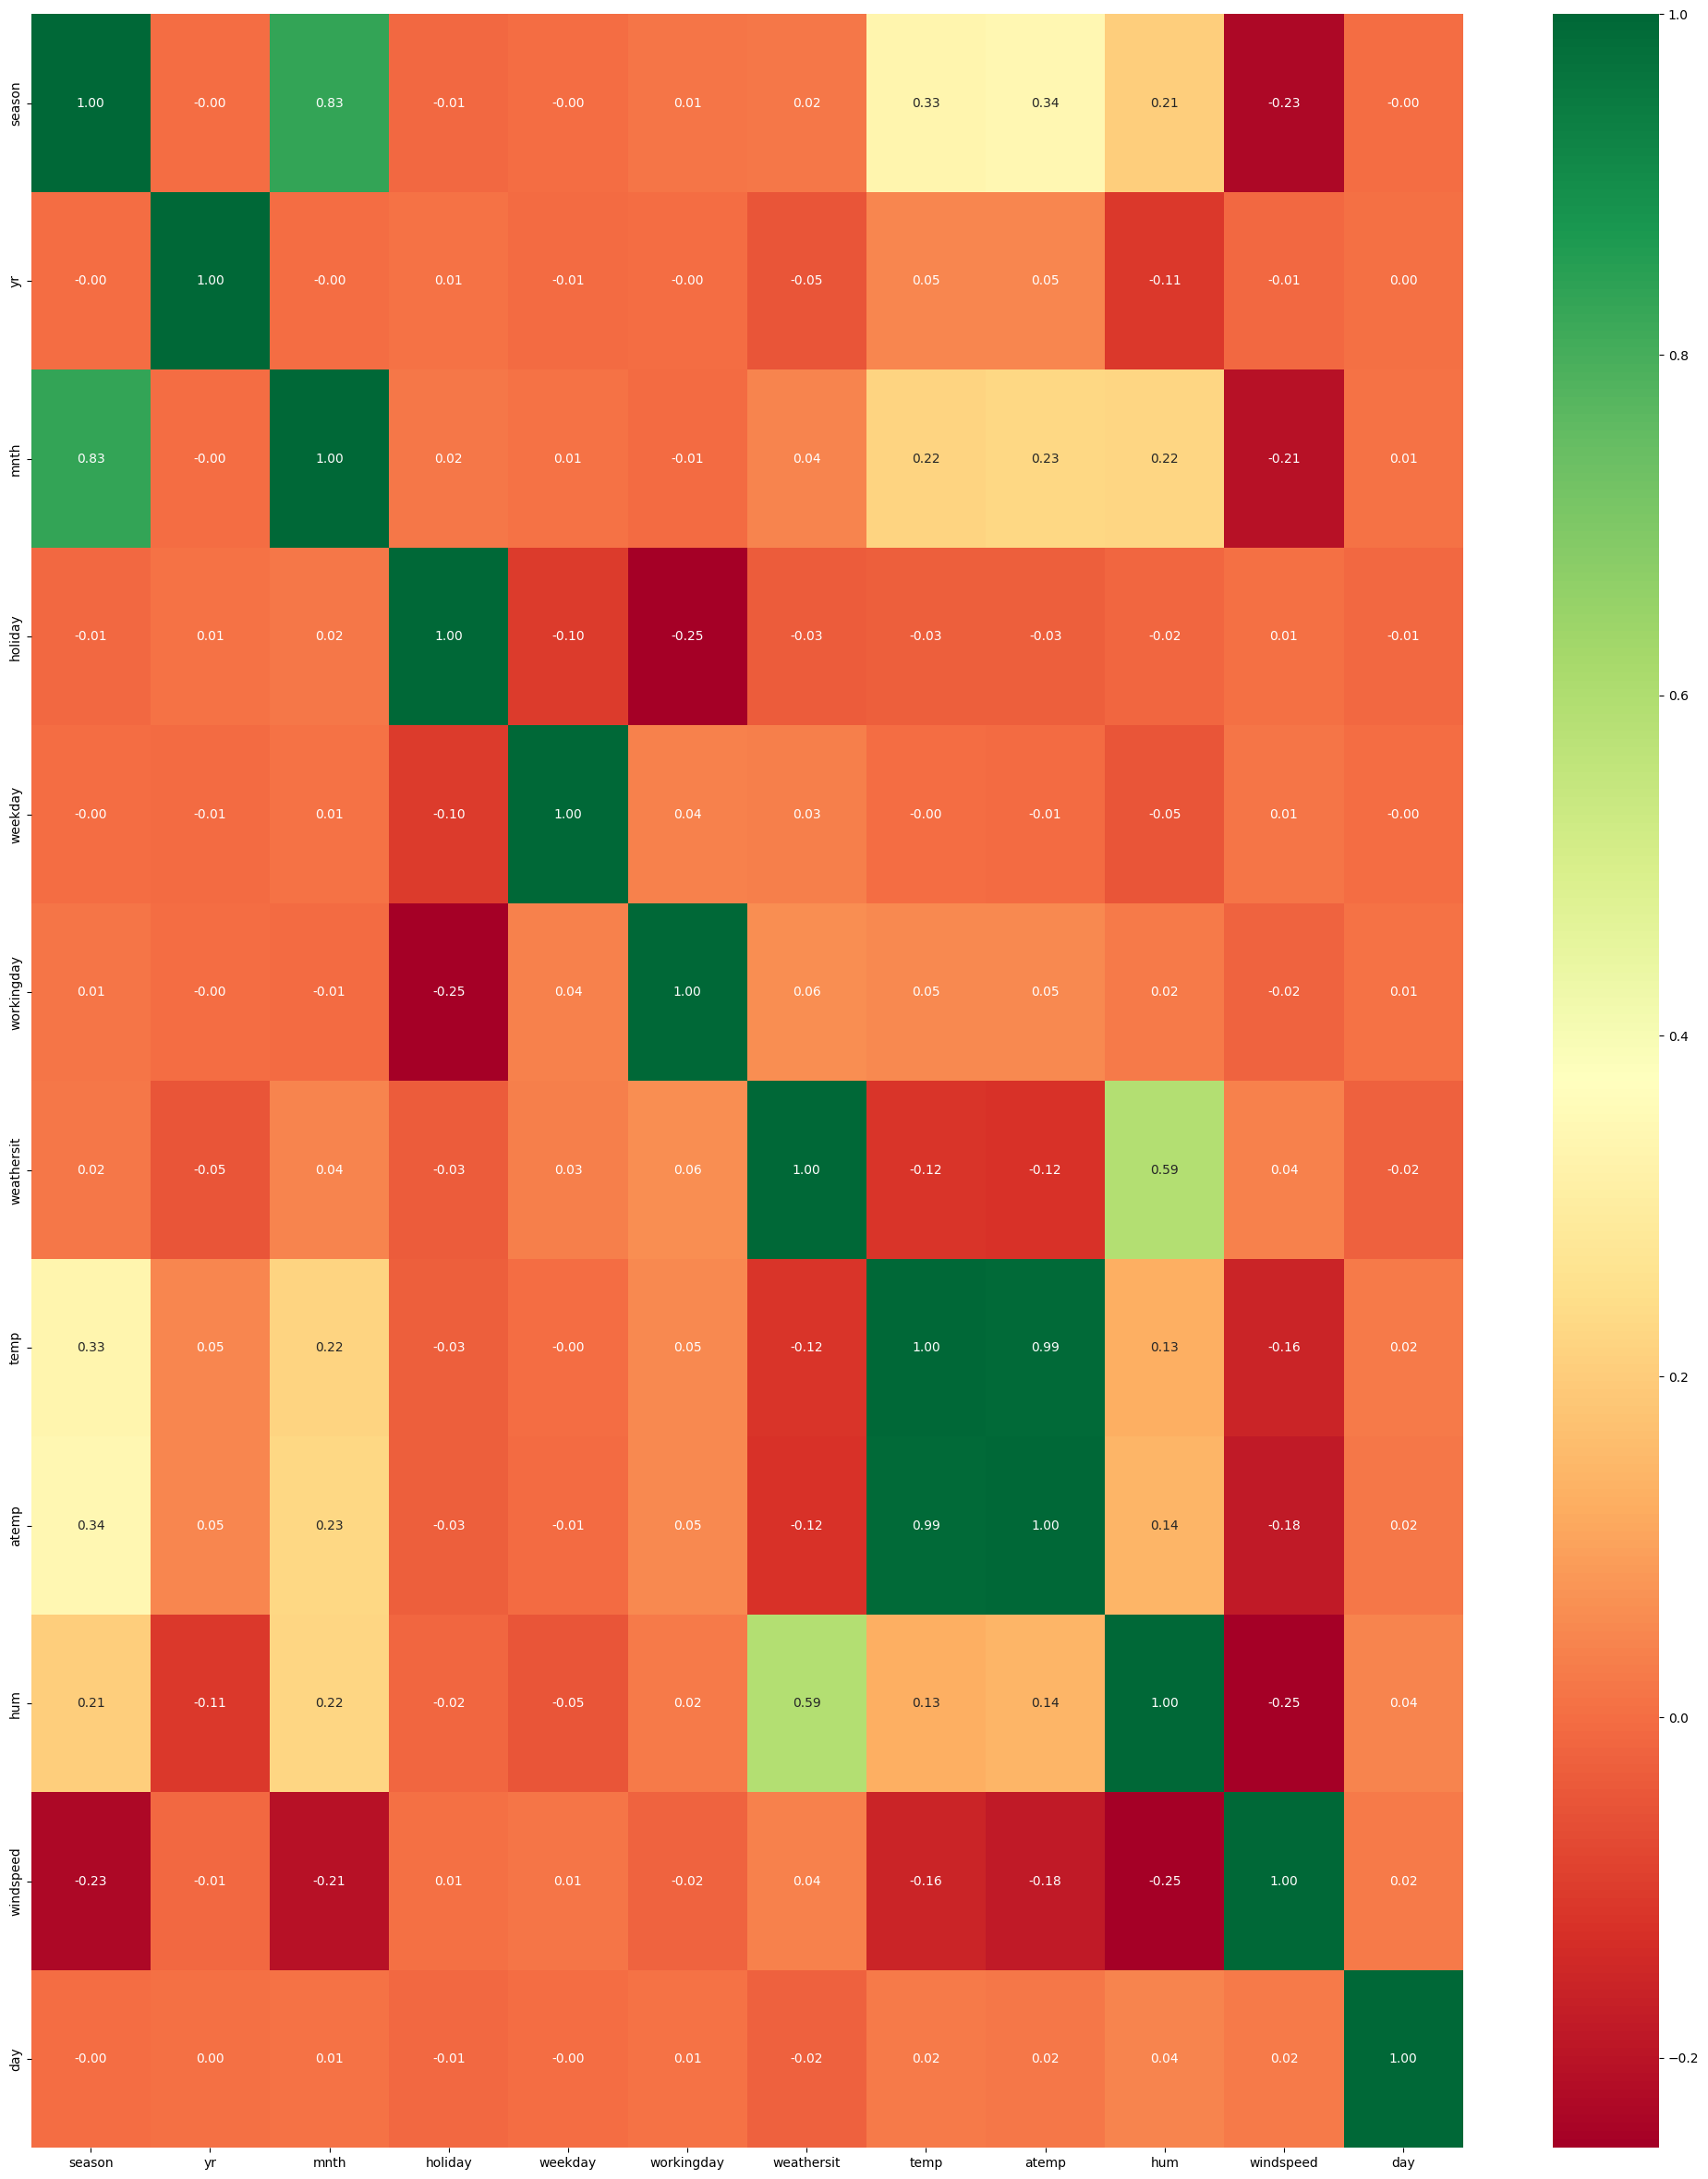

In [ ]:
plt.figure(figsize=(25,30))
# Drop target variables from correlation heatmap
sns.heatmap(df.drop(columns=['casual', 'registered', 'cnt','instant']).corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.show()

In [ ]:


# Calculate correlation
correlation = df[['mnth', 'season']].corr()
print(correlation)

           mnth   season
mnth    1.00000  0.83144
season  0.83144  1.00000


Step 1: Analyze the Correlation:
- Correlation between mnth and season=0.8314
- Since this is a strong correlation (>0.8), it indicates redundant information, meaning we should consider removing one.

Step 2: Which One to Drop?
Drop season and Keep mnth:
  - mnth contains more detailed information.
  - season is derived from mnth (Spring: 3-5, Summer: 6-8, Fall: 9-11, Winter: 12-2).
  - Keeping mnth allows models to learn seasonal patterns without losing month-level details.

In [ ]:
correlation = df[['temp', 'atemp']].corr()
print(correlation)

           temp     atemp
temp   1.000000  0.991702
atemp  0.991702  1.000000


Difference Between temp and atemp:

1)temp- Actual temperature  Measured by a thermometer (in Celsius, scaled between 0-1)-Raw temperature value.

2)atemp-  Feels-like temperature  Calculated using temp, humidity, and wind speed-  Reflects human perception of temperature.

3)Key Differences:

-temp is the actual air temperature, while atemp is the perceived (feels-like) temperature.

-atemp accounts for humidity and wind, making it more useful for predicting human behavior (e.g., bike rentals).

-On a windy or humid day, temp and atemp can be very different, but on normal days, they are very close (which explains their 0.99 correlation).

4)Which One to Keep?
-Since bike rentals depend more on how people feel rather than the raw     temperature, we keep atemp and drop temp.

**Feature Selection after dropping  High correlation**

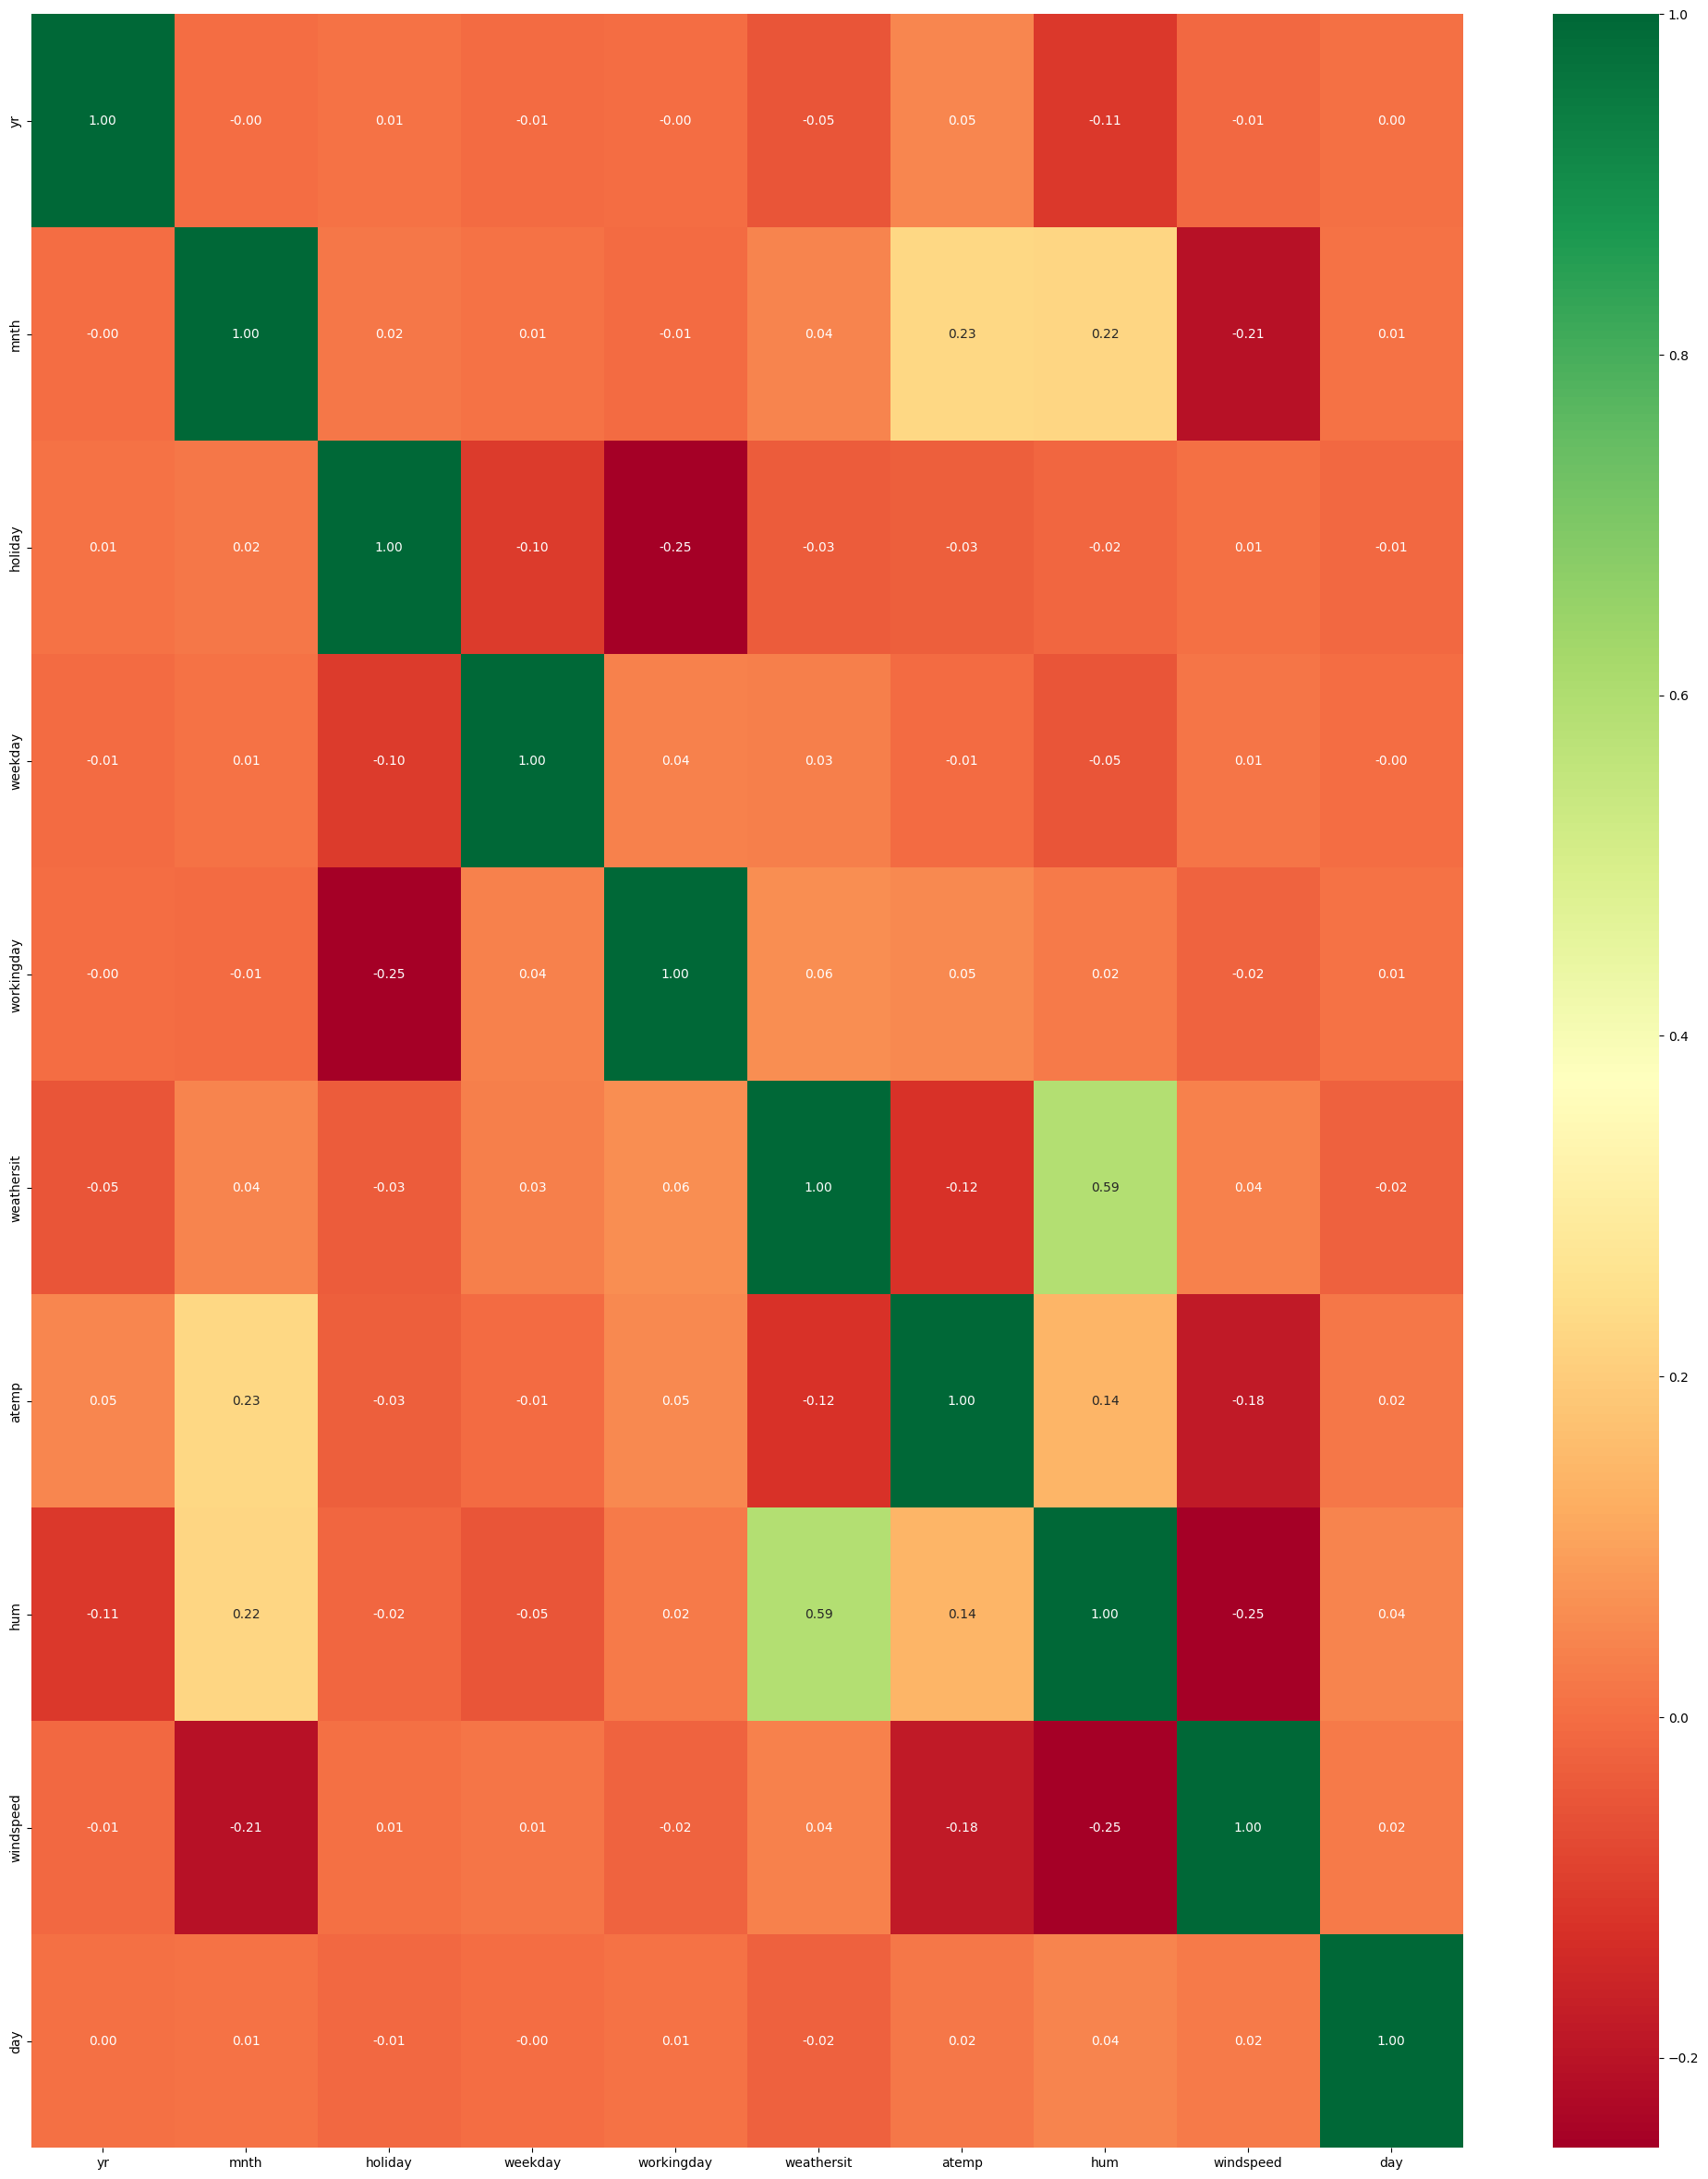

In [ ]:

plt.figure(figsize=(25,30))
# Drop target variables from correlation heatmap
sns.heatmap(df.drop(columns=['casual', 'registered', 'cnt','instant','temp','season']).corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.show()

In [ ]:
df.drop(columns=['casual', 'registered','instant','temp','season'], inplace=True)

In [ ]:
df

,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,day
0,0,1,0,6,0,2,0.363625,0.805833,0.160446,985,1
1,0,1,0,0,0,2,0.353739,0.696087,0.248539,801,2
2,0,1,0,1,1,1,0.189405,0.437273,0.248309,1349,3
3,0,1,0,2,1,1,0.212122,0.590435,0.160296,1562,4
4,0,1,0,3,1,1,0.229270,0.436957,0.186900,1600,5
...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,0,4,1,2,0.226642,0.652917,0.350133,2114,27
727,1,12,0,5,1,2,0.255046,0.590000,0.155471,3095,28
728,1,12,0,6,0,2,0.242400,0.752917,0.124383,1341,29
729,1,12,0,0,0,1,0.231700,0.483333,0.350754,1796,30


# Univariate Analysis

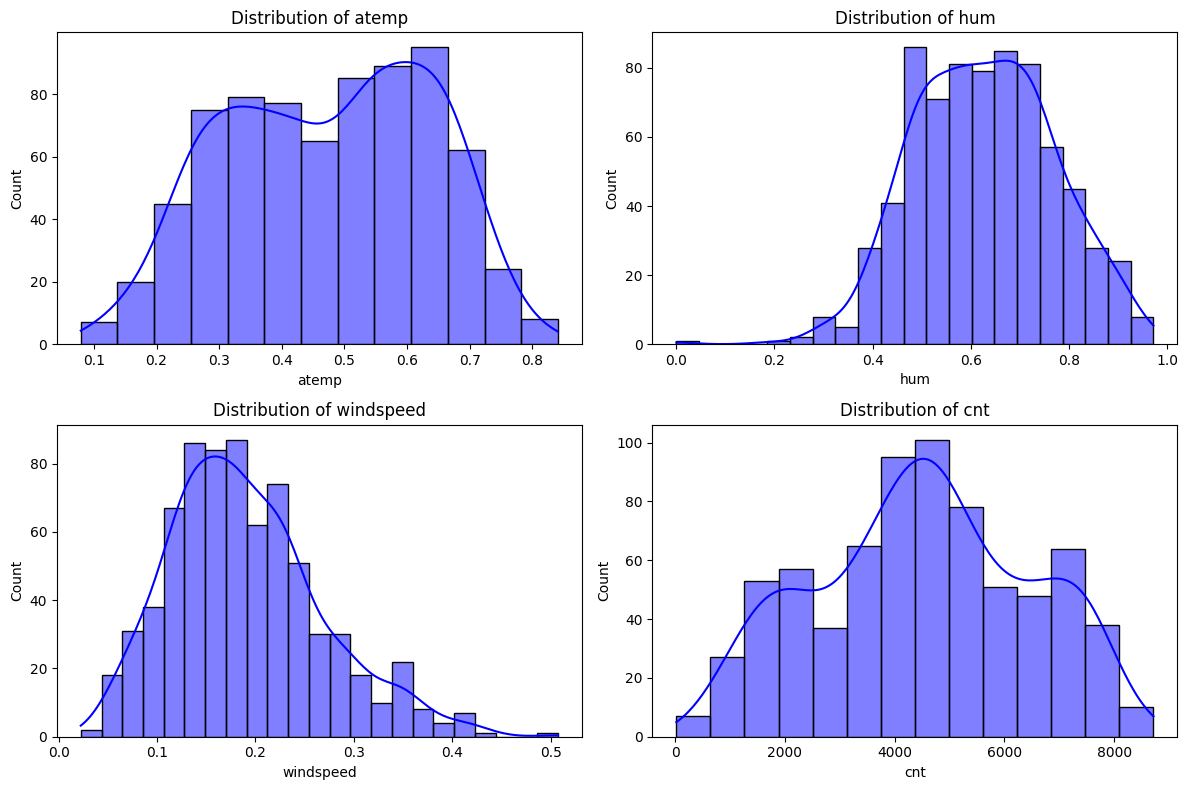

In [ ]:
#For numerical columns
num_col = ['atemp', 'hum', 'windspeed', 'cnt']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(num_col, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True, color="blue")
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()


1) Feels-like Temperature (atemp)

Most rides happen when the weather feels comfortable, between 0.3 and 0.7.

Very hot or very cold days are less common for bike rentals.

2) Humidity (hum)

People rent bikes more when humidity is moderate (around 0.5 to 0.8).

Very dry or very humid days see fewer rentals.

3) Windspeed

Low wind speeds (0.1 to 0.3) are common when bikes are rented.

High wind makes it harder to ride, so rentals are fewer on windy days.

4) Total Rentals (cnt)

Most days have 4000 to 5000 rentals.

Very few days have extremely low or high rental counts

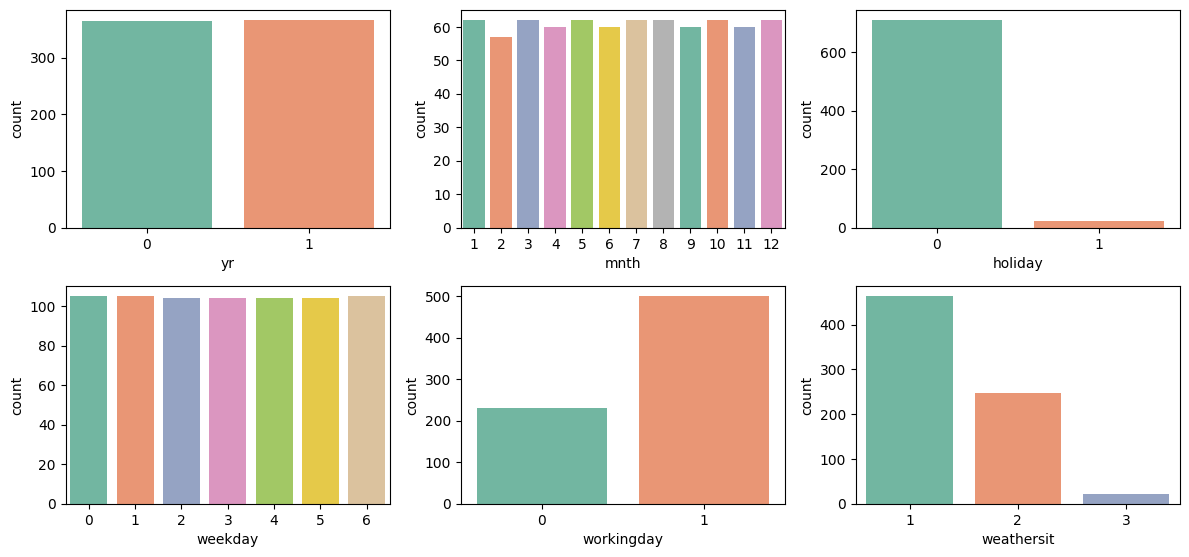

In [ ]:
cat_col=df[['yr','mnth','holiday','weekday','workingday','weathersit']]
plt.figure(figsize=(12,8))
plotnumber=1
for i in cat_col:
  if plotnumber<=6:
    plt.subplot(3,3,plotnumber)
    sns.countplot(data=cat_col,x=cat_col[i], palette="Set2")
    plt.xlabel(i)

    plotnumber+=1
plt.tight_layout()

1) Year (yr)

Data is evenly split between two years (likely 2011 and 2012).

So, the model sees almost equal data from both years.

2) Month (mnth)

Bike rentals happen consistently across all months.

No major drop in any particular month—people rent bikes all year round.

3) Holiday

Most bike rentals are on non-holidays.

People rent bikes less on holidays.

4) Weekday

Rentals are fairly evenly spread across all weekdays (Monday to Sunday).

No big difference between weekdays and weekends in terms of count.

5) Working Day

More rentals are recorded on working days than non-working days.

Likely due to people using bikes for commuting to work or school.

6) Weather Situation (weathersit)

Most rentals happen when the weather is clear or partly cloudy (1).

Fewer rides in misty or rainy conditions (2 & 3).

Bad weather clearly reduces bike usage.

<Axes: xlabel='day', ylabel='count'>

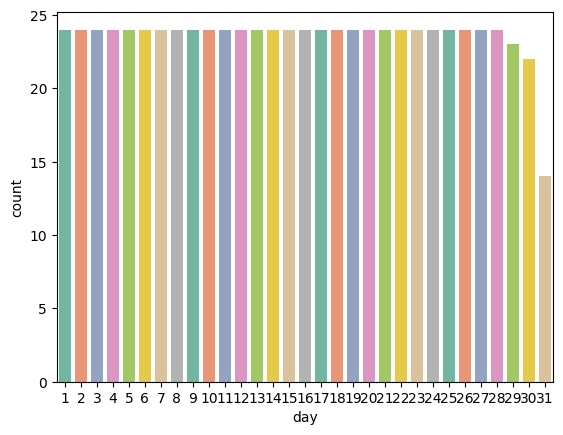

In [ ]:
sns.countplot(data=df,x=df.day, palette="Set2")

# Bivariate Analysis

-To Analyze the Target Variable (cnt)

-Compare cnt with numerical predictors (to check relationships).

<Axes: xlabel='atemp', ylabel='cnt'>

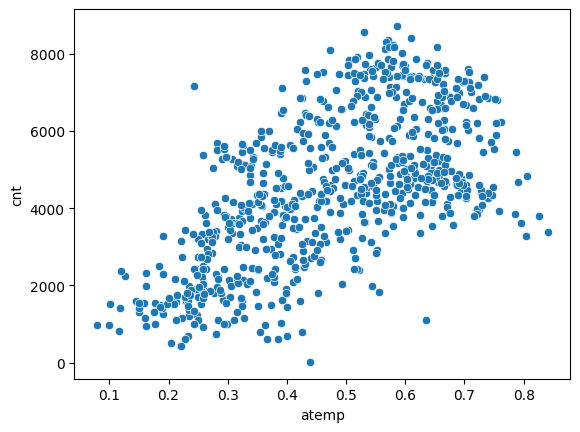

In [ ]:
sns.scatterplot(data=df, x='atemp', y='cnt')

<Axes: xlabel='hum', ylabel='cnt'>

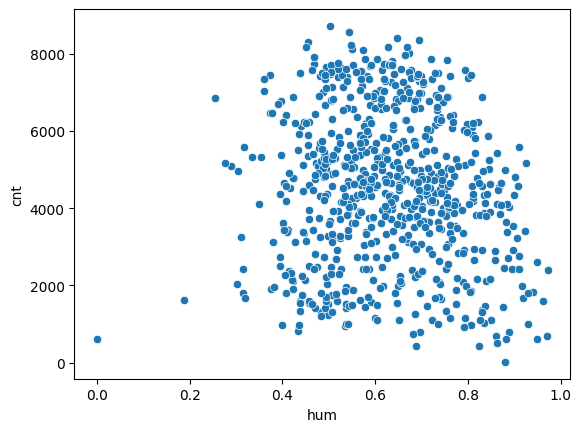

In [ ]:
sns.scatterplot(data=df, x='hum', y='cnt')

<Axes: xlabel='windspeed', ylabel='cnt'>

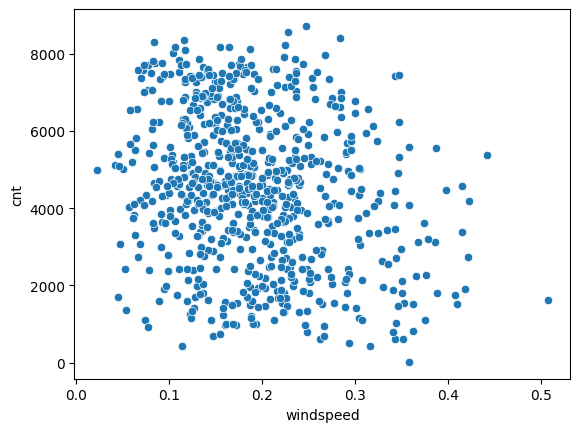

In [ ]:
sns.scatterplot(data=df, x='windspeed', y='cnt')

-To Check Feature Relationships.

-Scatter plots can confirm collinearity visually.

-Since heatmap shows strong correlations, plotted scatterplot to double-check relationships

<Axes: xlabel='atemp', ylabel='hum'>

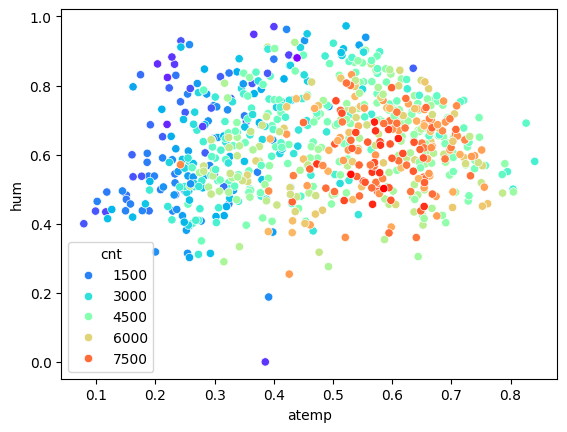

In [ ]:
sns.scatterplot(data=df,x=df['atemp'],y=df['hum'],hue=df.cnt,palette="rainbow")

<Axes: xlabel='atemp', ylabel='windspeed'>

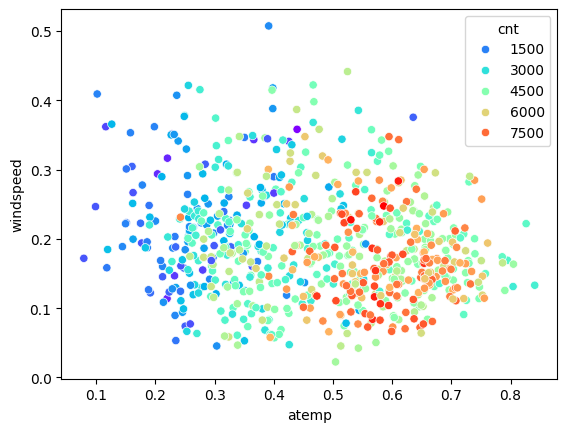

In [ ]:
sns.scatterplot(data=df, x='atemp', y='windspeed',hue=df.cnt,palette="rainbow")

<Axes: xlabel='hum', ylabel='windspeed'>

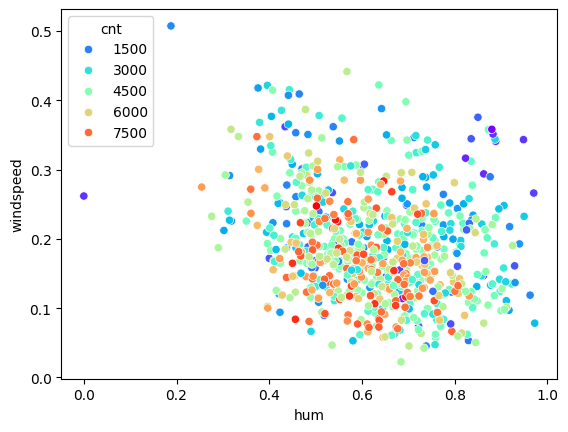

In [ ]:
sns.scatterplot(data=df, x='hum', y='windspeed',hue=df.cnt,palette="rainbow")

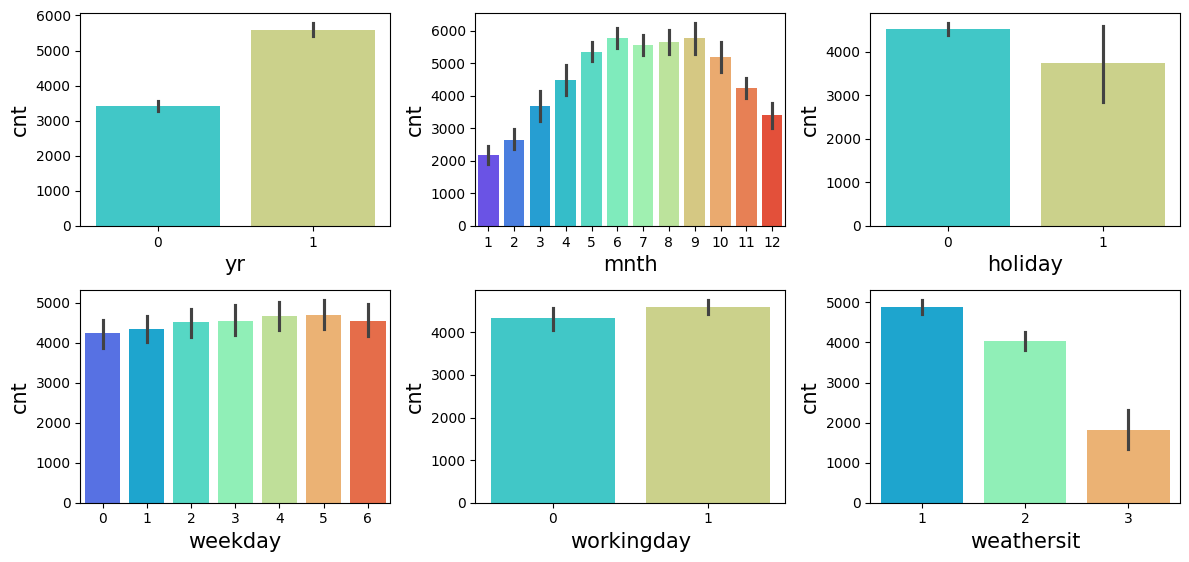

In [ ]:
#creating barplot for categorical columns
cat_col=df[['yr','mnth','holiday','weekday','workingday','weathersit']]
plt.figure(figsize=(12,8))
plotnumber=1
for i in cat_col:
  if plotnumber<=9:
    plt.subplot(3,3,plotnumber)
    sns.barplot(data=cat_col,x=cat_col[i],y=df.cnt,palette='rainbow')
    plt.xlabel(i,fontsize=15)
    plt.ylabel('cnt',fontsize=15)
    plotnumber+=1
plt.tight_layout()

1. Year (yr):

More people rented bikes in year 1 than in year 0.

Bike rentals increased over time.



2. Month (mnth):

Rentals are highest in summer months (May to September).

Fewer rentals in winter months like January and December.



3. Holiday:

More bikes are rented on non-holidays than on holidays.



4. Weekday:

Bike rentals are quite similar across all weekdays.

No big change between Monday to Sunday.



5. Working Day:

Bike rentals are slightly higher on working days than on non-working days.



6. Weather Situation (weathersit):

Rentals are highest when the weather is good (clear or few clouds).

Rentals drop when the weather gets worse (like rain or snow).

#Data Preprocessing

In [ ]:
df.isnull().sum()

,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
atemp,0
hum,0
windspeed,0
cnt,0


In [ ]:
df.duplicated().sum()

np.int64(0)

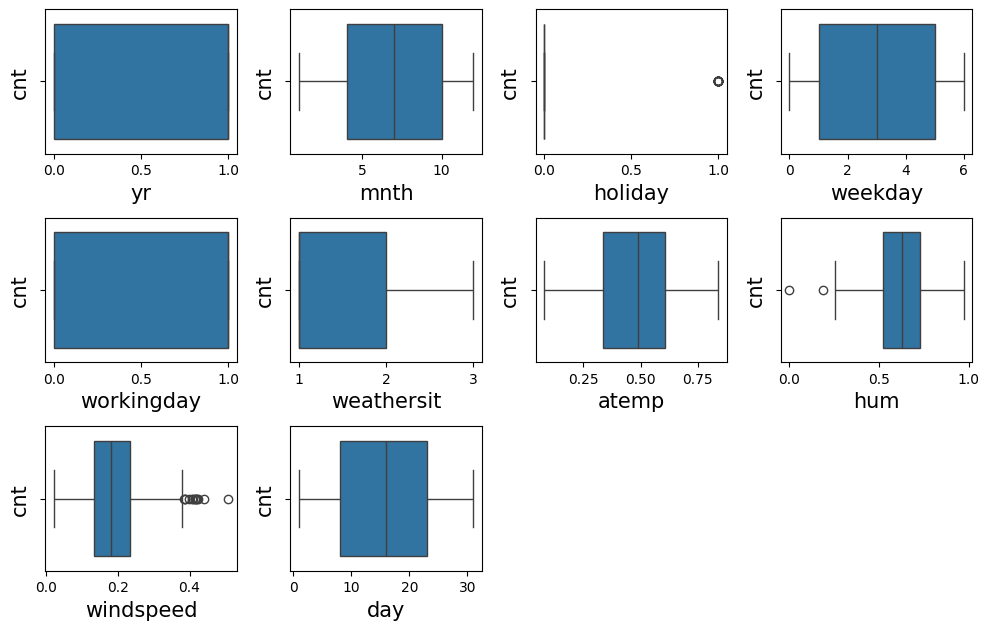

In [ ]:
#creating boxplot for numerical columns
plt.figure(figsize=(10,8))
plotnumber=1
for i in df.drop('cnt',axis=1):
  if plotnumber<=12:
    plt.subplot(4,4,plotnumber)
    sns.boxplot(data=df,x=df[i])
    plt.xlabel(i,fontsize=15)
    plt.ylabel('cnt',fontsize=15)
    plotnumber+=1
plt.tight_layout()


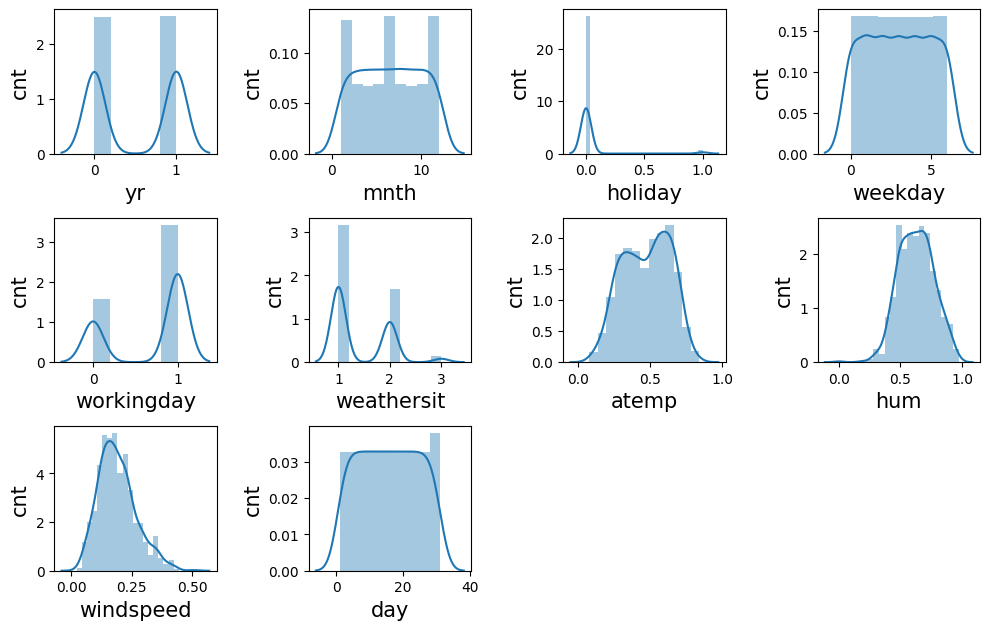

In [ ]:
#creating distplot for numerical columns to know which rule to use whether IQR or 3 sigma
plt.figure(figsize=(10,8))
plotnumber=1
for i in df.drop('cnt',axis=1):
  if plotnumber<=12:
    plt.subplot(4,4,plotnumber)
    sns.distplot(x=df[i])
    plt.xlabel(i,fontsize=15)
    plt.ylabel('cnt',fontsize=15)
    plotnumber+=1
plt.tight_layout()

# Handling Outliers for hum and windspeed

In [ ]:
# Handling Outliers
Q1=df['hum'].quantile(0.25)
print("lower quartile",Q1)
Q3=df['hum'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 0.52
upper quartile 0.7302085


In [ ]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(0.21020850000000002)

In [ ]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is 0.20468725
upper_limit 1.0455212500000002


In [ ]:
# Find values above upper_limit
df.loc[df['hum']>upper_limit]

,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,day


In [ ]:
# Find percentage of outliers
len(df.loc[df['hum']>upper_limit])/len(data)

0.0

In [ ]:
# Find values below lower_limits
df.loc[df['hum']<lower_limit]

,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,day
49,0,2,0,6,0,1,0.391404,0.187917,0.507463,1635,19
68,0,3,0,4,1,3,0.385668,0.000000,0.261877,623,10


In [ ]:
# How to handle outliers
# since data is not normal will replace outliers with median
df.loc[df['hum']<lower_limit,"hum"]=df['hum'].median()

<Axes: xlabel='hum'>

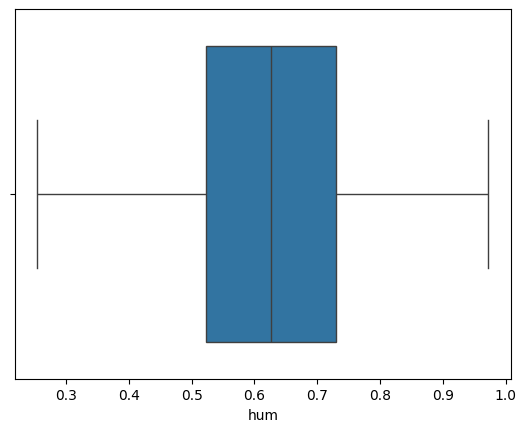

In [ ]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df.hum)

In [ ]:
# Handling Outliers
Q1=df['windspeed'].quantile(0.25)
print("lower quartile",Q1)
Q3=df['windspeed'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 0.13495
upper quartile 0.2332145


In [ ]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(0.0982645)

In [ ]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is -0.012446750000000034
upper_limit 0.38061125


In [ ]:
# Find values above upper_limit
df.loc[df['windspeed']>upper_limit]

,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,day
44,0,2,0,1,1,1,0.398350,0.375833,0.417908,1913,14
49,0,2,0,6,0,1,0.391404,0.626667,0.507463,1635,19
93,0,4,0,1,1,1,0.542929,0.426250,0.385571,3115,4
94,0,4,0,2,1,2,0.398350,0.642083,0.388067,1795,5
292,0,10,0,4,1,1,0.466525,0.636250,0.422275,4195,20
382,1,1,0,3,1,1,0.275254,0.443333,0.415429,3376,18
407,1,2,0,0,0,1,0.101658,0.464583,0.409212,1529,12
420,1,2,0,6,0,1,0.255675,0.395833,0.421642,2732,25
432,1,3,0,4,1,1,0.524604,0.567500,0.441563,5382,8
433,1,3,0,5,1,2,0.397083,0.407083,0.414800,4569,9


In [ ]:
# Find percentage of outliers
len(df.loc[df['windspeed']>upper_limit])/len(data)

0.017783857729138167

In [ ]:
# Find values below lower_limits
df.loc[df['windspeed']<lower_limit]

,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,day


In [ ]:
# How to handle outliers
# since data is not normal will replace outliers with median
df.loc[df['windspeed']>upper_limit,"windspeed"]=df['windspeed'].median()

<Axes: xlabel='windspeed'>

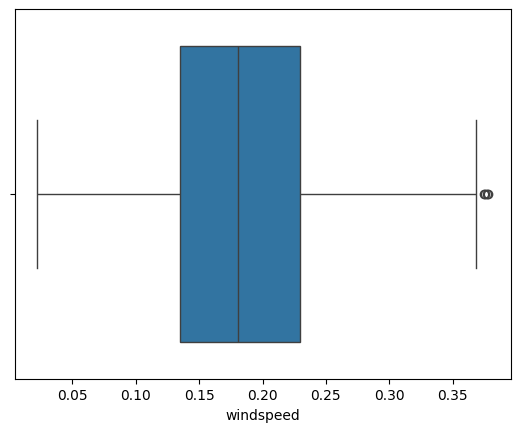

In [ ]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df.windspeed)

In [ ]:
df['windspeed'] = np.log1p(df['windspeed'])  # used log Transformation because data is right skewed data

Why Use np.log1p() Instead of np.log()?

np.log1p(x) computes log(1 + x), which is safer than np.log(x), because:

If x = 0, then log(0) is undefined, but log1p(0) = log(1) = 0.

It avoids errors caused by taking the log of zero.

It works well with data that has small values or zeroes.

Example Calculation

Let's assume we have the following cnt values:

cnt (original)  log(1 + cnt)

0 log(1 + 0) = log(1) = 0.000

10  log(1 + 10) = log(11) ≈ 2.398

100 log(1 + 100) = log(101) ≈ 4.615

1000  log(1 + 1000) = log(1001) ≈ 6.908

<Axes: xlabel='windspeed'>

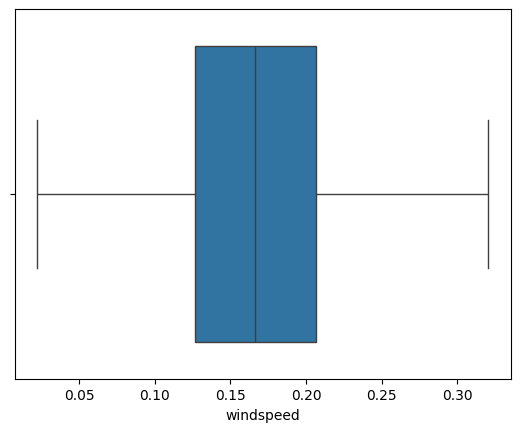

In [ ]:
sns.boxplot(x=df['windspeed'])

# Model Creation

In [ ]:
x=df.drop('cnt', axis=1)
y=df['cnt']

In [ ]:
# Split data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
x_train.shape

(584, 10)

In [ ]:
x_test.shape

(147, 10)

In [ ]:
y_train.shape

(584,)

In [ ]:
y_test.shape

(147,)

In [ ]:
y_test

,cnt
703,6606
33,1550
300,3747
456,6041
633,7538
...,...
70,2132
192,4258
328,2792
165,5180


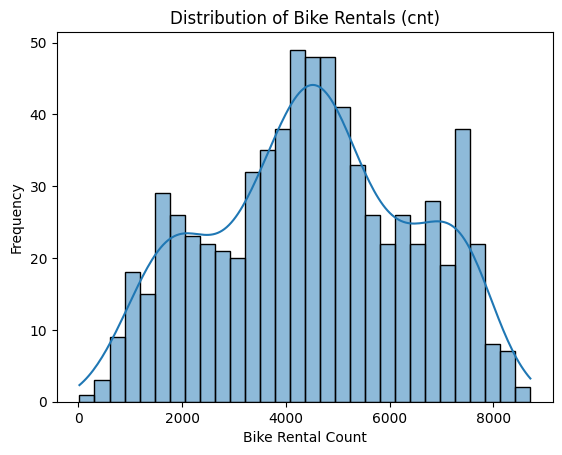

In [ ]:
 #Checking whether the output is balanced or not,since the data is Reggressor
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of Bike Rentals (cnt)")
plt.xlabel("Bike Rental Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#step 2: checked for skewness because the cnt is reggressor data
# (If skewness is |skew| < 1, no transformation is needed. If |skew| > 1, apply log or power transformation.)
from scipy.stats import skew
print(f"Skewness of cnt: {skew(df['cnt']):.2f}")

Skewness of cnt: -0.05


# 1)Linear Regression

In [ ]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression
# Initialise model
LR=LinearRegression()
# Train model with x_train and y_train
LR.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Make prediction /Test model
y_pred_LR=LR.predict(x_test)
y_pred_LR
y_pred_LRTrain=LR.predict(x_train)
y_pred_LRTrain

array([ 4.32902413e+03,  3.16810019e+03,  3.62190120e+03,  3.73223447e+03,
        6.87984751e+03,  3.03373153e+03,  4.57236079e+03,  1.30158378e+03,
        3.08795280e+03,  4.63331323e+03,  6.64813531e+03,  2.82301318e+03,
        4.77330033e+03,  5.45401025e+03,  3.13180451e+03,  3.97542609e+03,
        5.33505908e+03,  2.12880923e+03,  2.97972434e+03,  6.03123222e+03,
        2.21778057e+03,  3.01183030e+03,  5.63598737e+03,  6.84934791e+03,
        4.58929414e+03,  1.11213874e+03,  3.98073983e+03,  4.75797366e+03,
        5.48368002e+03,  4.78388577e+03,  7.53607921e+03,  3.45811249e+03,
        1.30852316e+03,  5.06485554e+02,  6.47817969e+03,  6.98957321e+03,
        4.77523960e+03,  6.15159337e+03,  6.40902795e+03,  7.22818831e+03,
        2.91164763e+03,  5.09536362e+03,  1.36479969e+03,  6.77283177e+03,
        3.95748270e+03,  4.17019686e+03,  4.92249577e+03,  2.21412418e+03,
        2.08014128e+03,  5.60638179e+03,  3.71777728e+03,  1.49917555e+03,
        5.22556449e+03,  

In [ ]:
# slopes/coefficients of x
LR.coef_

array([ 1.99516833e+03,  9.96952534e+01, -5.07701406e+02,  7.15523980e+01,
        1.65710673e+02, -6.14304370e+02,  6.41633323e+03, -9.52077719e+02,
       -2.13010637e+03, -5.50958534e+00])

In [ ]:
# intercept
LR.intercept_

np.float64(1412.5224054241771)

# Evaluate the model

 Error formula/loss Functions-Know the difference between actual and predicted values
 Different Error/Loss Functions in Regression algorithm are
* MSE(Mean Squared error)
* MAE(Mean absolute error)
* RMSE(Root mean squared error)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
# MSE
MSE=mean_squared_error(y_test,y_pred_LR)
MSE

809075.4333405385

In [ ]:
# MAE
MAE=mean_absolute_error(y_test,y_pred_LR)
MAE


687.9896722678188

In [ ]:
# RMSE
RMSE_LR=np.sqrt(MSE)
RMSE_LR

np.float64(899.4862051974663)

In [ ]:
#r2_score
test_r2_LR=r2_score(y_test,y_pred_LR)
test_r2_LR

0.7982296299210433

In [ ]:
train_r2=r2_score(y_train,y_pred_LRTrain)
train_r2

0.7653815278730169

In [ ]:
ad_r2_LR=1-(1-0.7983614148090707)*(147-1)/(147-10-1)

In [ ]:
ad_r2_LR

0.7835350482509142

# 2) SVM

steps :

1)Splitting data into training and testing sets.

2)Scaling features to improve SVR performance.

3)Hyperparameter Tuning using RandomizedSearchCV to find the best SVR configuration.

4)Making Predictions on unseen data (test set).

5)Evaluating the model using RMSE and R².

6)Visualizing the predictions to assess performance visually.

Optimized SVR RMSE: 948.25, R²: 0.7758


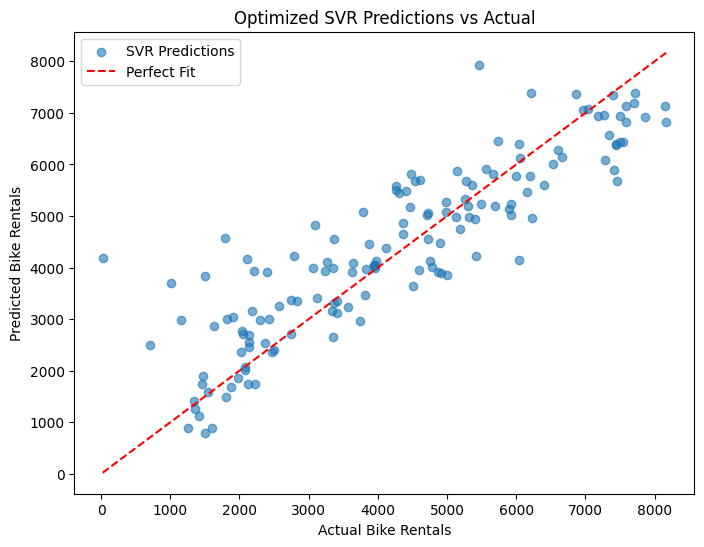

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import uniform




# Feature Scaling (fit on training data only)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Hyperparameter Tuning for SVR
svr = SVR()
svr_param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.01, 1),
    'epsilon': uniform(0.01, 0.5),
    'kernel': ['rbf', 'poly', 'linear']
}

# Randomized Search for SVR (Hyperparameter Tuning with RandomizedSearchCV)
svr_random = RandomizedSearchCV(svr, param_distributions=svr_param_dist,
                                n_iter=20, cv=5, scoring='neg_mean_squared_error', random_state=42)
svr_random.fit(x_train_scaled, y_train)
best_svr = svr_random.best_estimator_

# Predictions & Evaluation
y_pred_svr = best_svr.predict(x_test_scaled)

# Performance Metrics
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

# Results
print(f"Optimized SVR RMSE: {rmse_svr:.2f}, R²: {r2_svr:.4f}")

# Plot Actual vs Predicted (SVR)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.6, label="SVR Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', label="Perfect Fit")
plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Optimized SVR Predictions vs Actual")
plt.legend()
plt.show()


# 3) Random Forest Regressor

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Random Forest (Tuned) Performance:
Train R²: 0.951
Test R²: 0.874
Train RMSE: 422.05
Test RMSE: 709.59


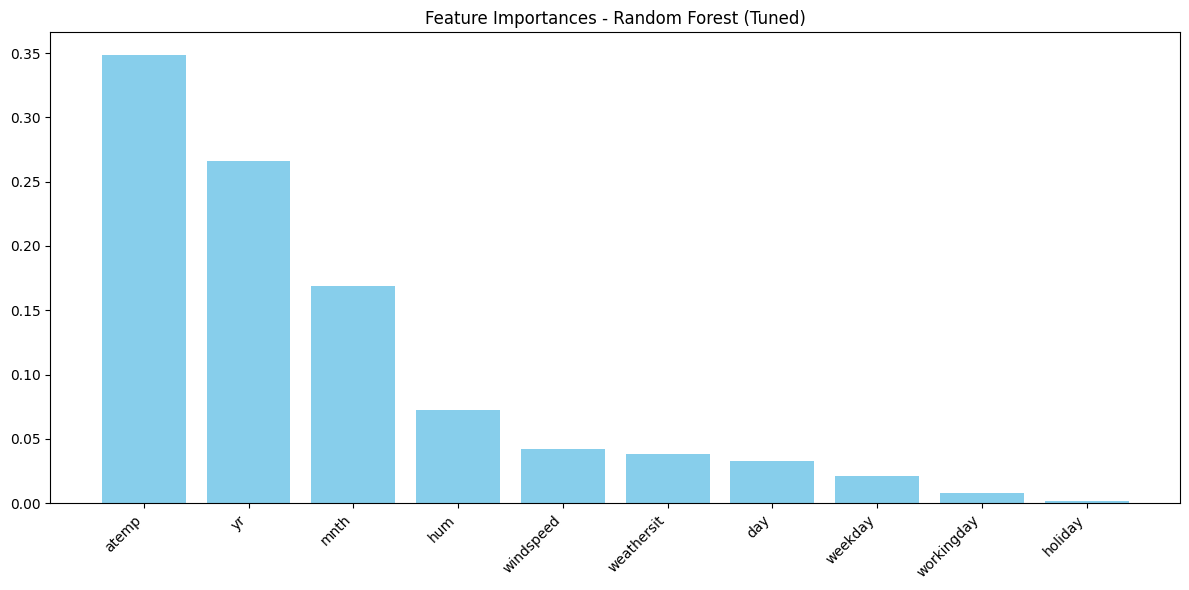

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define Model
rf = RandomForestRegressor(random_state=42)

# Step 2: Adjusted Parameter Grid for Stronger Regularization
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Step 3: Train Model with GridSearchCV
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,                            # 5-Fold Cross-Validation
                           scoring='r2',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(x_train, y_train)
best_rf = grid_search.best_estimator_

# Step 4: Predictions
y_train_pred = best_rf.predict(x_train)
y_test_pred = best_rf.predict(x_test)

# Step 5: Evaluation
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display Performance Metrics
print("Best Parameters:", grid_search.best_params_)
print("\nRandom Forest (Tuned) Performance:")
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

# Step 6: Feature Importance Plot
importances = best_rf.feature_importances_
feature_names = x.columns
indices = np.argsort(importances)[::-1]

# Plot Top 10 Important Features
plt.figure(figsize=(12, 6))
plt.title("Feature Importances - Random Forest (Tuned)")
plt.bar(range(len(importances)), importances[indices], align="center", color='skyblue')

# Display Top 10 Features for Clarity
top_n = 10
plt.xticks(range(min(top_n, len(importances))),
           feature_names[indices][:top_n],
           rotation=45, ha='right')

plt.tight_layout()
plt.show()


observation:

In RandomForest Regressor ,The most importance features are atemp,yr,mnth

# 4) XG Boost

1)install Libraries

In [ ]:
pip install xgboost scikit-learn pandas numpy matplotlib

2) Scaling

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Standardize the feature variables
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

3) Train XGBoost model with default parameter

In [ ]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

# Initialize XGBoost regressor with default parameters
xgb_default = xgb.XGBRegressor(max_depth=4,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42)

# Train the model on the training data
xgb_default.fit(x_train_scaled, y_train)

# Predict on training and testing data
y_train_pred_default = xgb_default.predict(x_train_scaled)
y_test_pred_default = xgb_default.predict(x_test_scaled)

# Evaluate the model
train_r2_default = r2_score(y_train, y_train_pred_default)
test_r2_default = r2_score(y_test, y_test_pred_default)
train_rmse_default =np.sqrt(mean_squared_error(y_train, y_train_pred_default))
test_rmse_default = np.sqrt(mean_squared_error(y_test, y_test_pred_default))

print(f"Default Model - Train R²: {train_r2_default:.3f}")
print(f"Default Model - Test R²: {test_r2_default:.3f}")
print(f"Default Model - Train RMSE: {train_rmse_default:.2f}")
print(f"Default Model - Test RMSE: {test_rmse_default:.2f}")

Default Model - Train R²: 0.991
Default Model - Test R²: 0.901
Default Model - Train RMSE: 177.79
Default Model - Test RMSE: 631.64


4) Visualize the actual vs predicted before tuning

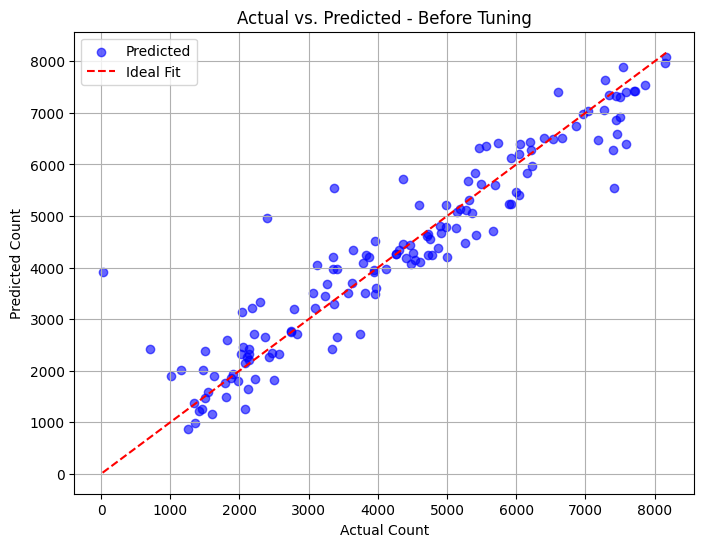

In [ ]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_default, alpha=0.6, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted - Before Tuning")
plt.legend()
plt.grid(True)
plt.show()

5) Hyperparameter Tuning with GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Initialize XGBoost regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='r2', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(x_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1}


6) Train XGBoost model with best parameters

In [ ]:
# Initialize XGBoost regressor with best parameters
xgb_best = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

# Train the model on the training data
xgb_best.fit(x_train_scaled, y_train)

# Predict on training and testing data
y_train_pred_best = xgb_best.predict(x_train_scaled)
y_test_pred_best = xgb_best.predict(x_test_scaled)

# Evaluate the model
train_r2_best = r2_score(y_train, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)
train_rmse_best = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))

print(f"Tuned Model - Train R²: {train_r2_best:.3f}")
print(f"Tuned Model - Test R²: {test_r2_best:.3f}")
print(f"Tuned Model - Train RMSE: {train_rmse_best:.2f}")
print(f"Tuned Model - Test RMSE: {test_rmse_best:.2f}")

Tuned Model - Train R²: 0.956
Tuned Model - Test R²: 0.895
Tuned Model - Train RMSE: 401.09
Tuned Model - Test RMSE: 649.19


7) Visualize the actual vs predicted after tuning

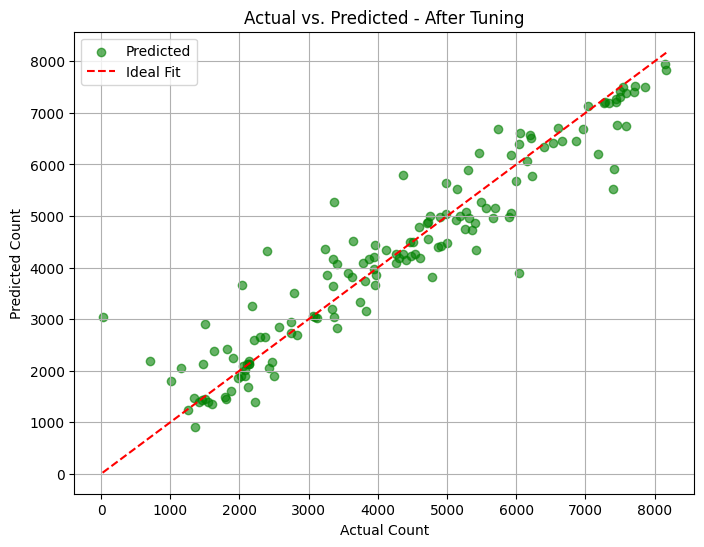

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_best, alpha=0.6, color='green', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs. Predicted - After Tuning")
plt.legend()
plt.grid(True)
plt.show()

8) Compare performances before and after Tuning

In [ ]:
print(f"Improvement in Test R²: {test_r2_best - test_r2_default:.3f}")
print(f"Reduction in Test RMSE: {test_rmse_default - test_rmse_best:.2f}")

Improvement in Test R²: 0.008
Reduction in Test RMSE: 23.79


9)Cross validation with Tuned Model

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(xgb_best, x_train_scaled, y_train, cv=5, scoring='r2')

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Average Cross-Validation R²: {cv_scores.mean():.3f}")

Cross-Validation R² Scores: [0.88367945 0.8733815  0.86989015 0.81765658 0.90480125]
Average Cross-Validation R²: 0.870


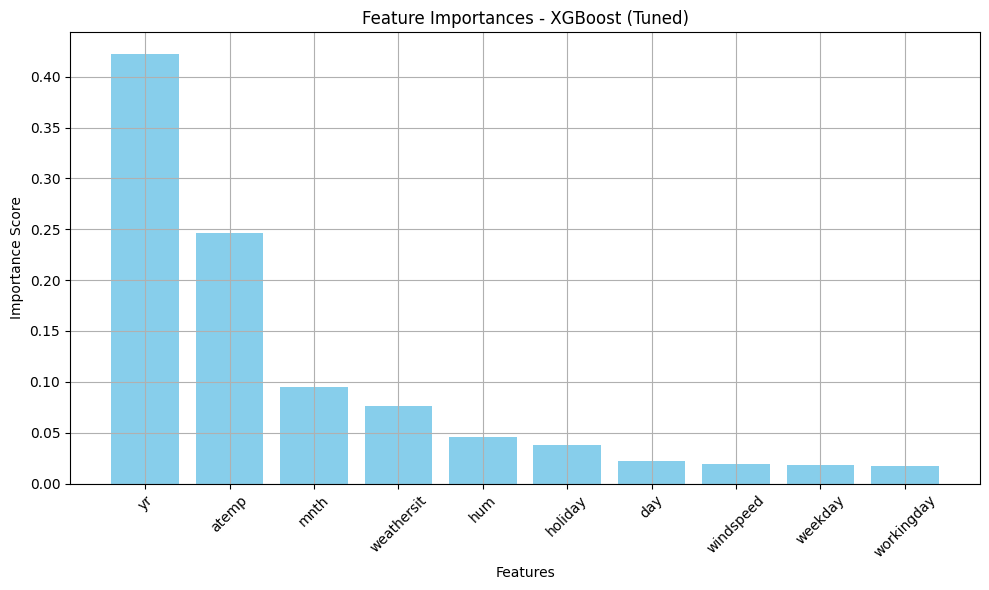

In [ ]:


# Get feature importances from your trained XGBoost model
xgb_importance = xgb_best.feature_importances_

# Create a DataFrame with feature names and importance scores
xgb_feat_imp_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(xgb_feat_imp_df['Feature'], xgb_feat_imp_df['Importance'], color='skyblue')
plt.title('Feature Importances - XGBoost (Tuned)')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

observation:

In XGBoost Regressor ,The most importance features are yr,atemp,mnth

# Bagging Regressor

In [ ]:

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np



# Feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



# Initialize Bagging Regressor with Decision Tree
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

# Train model
bagging_model.fit(x_train, y_train)

# Predictions
y_pred = bagging_model.predict(x_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Bagging RMSE: {rmse:.2f}")
print(f"Bagging R² Score: {r2:.4f}")

Bagging RMSE: 720.84
Bagging R² Score: 0.8704


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score



# 4. Scale features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



# 6. Define KNN and Bagging Regressor
knn = KNeighborsRegressor(n_neighbors=5)
bagging_knn = BaggingRegressor(estimator=knn, n_estimators=10, random_state=42, n_jobs=-1)

# 7. Train model
bagging_knn.fit(x_train, y_train)

# 8. Predict
y_pred = bagging_knn.predict(x_test)

# 9. Evaluate
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred))
r2_knn = r2_score(y_test, y_pred)

print(f"Bagging with KNN - RMSE: {rmse:.2f}")
print(f"Bagging with KNN - R² Score: {r2:.4f}")

Bagging with KNN - RMSE: 720.84
Bagging with KNN - R² Score: 0.8704


In [ ]:
!pip install tabulate

In [ ]:
from tabulate import tabulate

In [ ]:
Table = [["LR", RMSE_LR,test_r2_LR,ad_r2_LR],
        ["SVR", rmse_svr,r2_svr],
        ["Random_Forest(includes HT)",test_rmse,test_r2,],
        ["XGBoost(after HT)",test_rmse_best,test_r2_best,],
        ["Bagging_DT", rmse,r2],
        ["Bagging_Knn",rmse_knn,r2_knn]]





col_names1 = ["Algorithm", "RMSE", "R2", "ad_r2"]

print(tabulate(Table, headers = col_names1, tablefmt = "fancy_grid"))

╒════════════════════════════╤══════════╤══════════╤══════════╕
│ Algorithm                  │     RMSE │       R2 │    ad_r2 │
╞════════════════════════════╪══════════╪══════════╪══════════╡
│ LR                         │  899.486 │ 0.79823  │ 0.783535 │
├────────────────────────────┼──────────┼──────────┼──────────┤
│ SVR                        │  948.253 │ 0.775758 │          │
├────────────────────────────┼──────────┼──────────┼──────────┤
│ Random_Forest(includes HT) │  709.592 │ 0.87443  │          │
├────────────────────────────┼──────────┼──────────┼──────────┤
│ XGBoost(after HT)          │  649.193 │ 0.894897 │          │
├────────────────────────────┼──────────┼──────────┼──────────┤
│ Bagging_DT                 │  720.835 │ 0.870419 │          │
├────────────────────────────┼──────────┼──────────┼──────────┤
│ Bagging_Knn                │ 1486.76  │ 0.448751 │          │
╘════════════════════════════╧══════════╧══════════╧══════════╛


In [ ]:
Conclusion:
XG boost after HyperTuning it gives best value